# Statistics project

## Unlocking Customer Insights : A Statistical Investigation

# Importing Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
# importing dataset from the source
df = pd.read_csv(r"D:\Carrier247\Satistics\project\Dataset\US_Customer_Insights_Dataset.csv")

In [9]:
# preview of the dataset which is imported
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [11]:
# Checking the shape of the dataset
df.shape

(10675, 12)

In [12]:
# we can see that the given dataset have around 10675 row and 12 columns.

In [14]:
# checking the datatype and null values in the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [39]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'])
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

C:\Users\dipan\AppData\Local\Temp\ipykernel_12240\1755769297.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['JoinDate'] = pd.to_datetime(df['JoinDate'])
C:\Users\dipan\AppData\Local\Temp\ipykernel_12240\1755769297.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                10675 non-null  object        
 1   Name                      10675 non-null  object        
 2   State                     10675 non-null  object        
 3   Education                 10675 non-null  object        
 4   Gender                    10675 non-null  object        
 5   Age                       10675 non-null  int64         
 6   Married                   10675 non-null  object        
 7   NumPets                   10675 non-null  int64         
 8   JoinDate                  10675 non-null  datetime64[ns]
 9   TransactionDate           10675 non-null  datetime64[ns]
 10  MonthlySpend              10675 non-null  float64       
 11  DaysSinceLastInteraction  10675 non-null  int64         
dtypes: datetime64[ns](

In [42]:
# JoinDate and TransactionDate converted to datetime format for time-based analysis
# Now All columns are in proper format.

In [43]:
# Still for more clarification we can use isnull function in dataset for checking null value.
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [44]:
# we can see no null values present in each column our data is ready for analysis.

In [45]:
# Here we are checking for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

In [46]:
# Here we are removing duplicate values if thet present in dataset. since our dataset has no duplicate values then it will not remove anything.
df = df.drop_duplicates()

# Dicriptive statistics

In [24]:
# Here we are understanding dataset with the help of discribe function which shows min,median,min,max and so on.
df.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


# Understand Categorical vs Numerical

In [28]:
# Categorical columns
df.select_dtypes(include=['object']).columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married',
       'JoinDate', 'TransactionDate'],
      dtype='object')

In [30]:
# Numerical columns
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction'], dtype='object')

In [32]:
# checking each column with its unique values in numbers.
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

CustomerID: 1000
Name: 990
State: 10
Education: 5
Gender: 3
Age: 63
Married: 2
NumPets: 5
JoinDate: 731
TransactionDate: 1605
MonthlySpend: 9843
DaysSinceLastInteraction: 1605


In [33]:
# Dataset contains ~10,000+ records of customer behavior
# No missing values found (if true)
# The Dataset is Mix of categorical columns like (Gender, State, Education) and numerical columns like (Age, Spend)
# CustomerID is unique identifier in the Dataset
# MonthlySpend shows variability → good for analysis

In [38]:
# Checking the number of people in Genders columns category wise
df["Gender"].value_counts()

Gender
Male          3791
Non-Binary    3471
Female        3413
Name: count, dtype: int64

In [64]:
# Gender distribution is fairly balanced across Male, Female, and Non-Binary categories.

In [56]:
df["Education"].value_counts()

Education
Master         2269
Associate      2153
Bachelor       2127
High School    2120
PhD            2006
Name: count, dtype: int64

In [65]:
# Customers are fairly evenly distributed across education levels, with a slight concentration in Master's degree holders.

In [57]:
df["Married"].value_counts()

Married
No     5583
Yes    5092
Name: count, dtype: int64

In [58]:
# We can see that the Majority of peoples are Unmarried.

In [59]:
df["State"].value_counts()

State
California    1180
Florida       1152
Ohio          1145
Arizona       1087
New York      1085
Georgia       1080
Washington    1030
Colorado      1014
Texas          997
Illinois       905
Name: count, dtype: int64

In [66]:
# Customers are distributed across states with California having slightly higher representation, but overall distribution is fairly balanced.

### Mean, Median, Std on Numerical Columns

In [52]:
# Mean
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].mean()

Age                          49.474567
MonthlySpend                331.610315
DaysSinceLastInteraction    538.469883
dtype: float64

In [50]:
# Median
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].median()

Age                          49.00
MonthlySpend                282.11
DaysSinceLastInteraction    445.00
dtype: float64

In [51]:
# Standard Deviation
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].std()

Age                          18.221365
MonthlySpend                225.799253
DaysSinceLastInteraction    398.766747
dtype: float64

In [55]:
# Mode on Categorical Columns
df[['Gender', 'Education', 'Married']].mode()

,Gender,Education,Married
0,Male,Master,No


In [61]:
# Min & Max
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].agg(['min', 'max'])

,Age,MonthlySpend,DaysSinceLastInteraction
min,18,3.89,1
max,80,1740.42,1791


In [63]:
# From this we can find out the min age is 18 while the oldest one is 80 years
# the min MonthlySpend is 3.89 upto 1740.42 
# also the min number of days of customer since last interaction is 1 while max is  

## Descriptive Insights

In [67]:
# The average age of customers is around 49 years, indicating a middle-aged customer base.

# The average monthly spend is approximately 331 USD, with high variability (std ≈ 225),
# suggesting diverse spending behavior among customers.

# The median spend (~282 USD) is lower than the mean, indicating a right-skewed distribution,
# meaning a few customers spend significantly higher amounts.

# The average days since last interaction (~538 days) suggests that many customers are inactive,
# highlighting a potential customer churn risk.

# Gender distribution is fairly balanced across Male, Female, and Non-Binary categories.

# Customers are fairly evenly distributed across education levels, with a slight concentration in Master's degree holders.

# A slightly higher number of customers are unmarried compared to married.

# Customers are distributed across multiple states, with California having a slightly higher count,
# but overall distribution remains balanced.

# Data Visualization

## Histogram

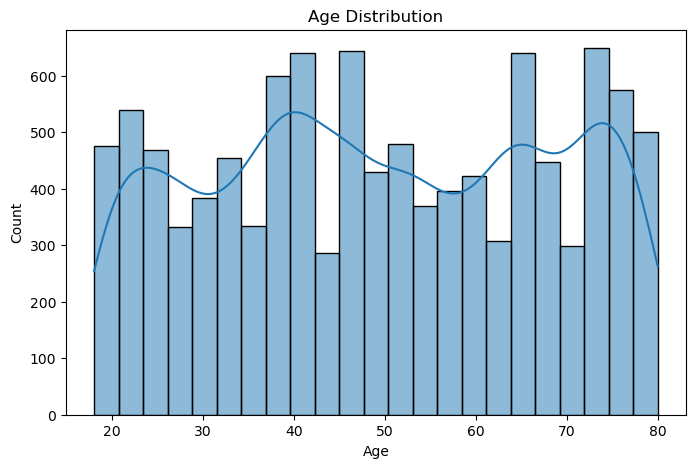

In [78]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [74]:
# Age distribution is fairly spread across all age groups (18–80),
# with no strong concentration in a specific age range.

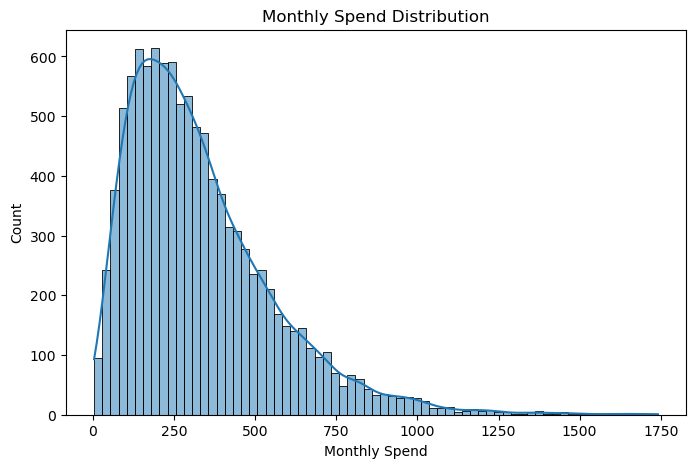

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlySpend'], kde=True)
plt.title("Monthly Spend Distribution")
plt.xlabel("Monthly Spend")
plt.ylabel("Count")
plt.show()

In [76]:
# The distribution of Monthly Spend is right-skewed,
# meaning most customers spend lower amounts while a few customers spend significantly higher.

# Most customers spend between 200 to 500 USD per month,
# while a small number of customers spend up to ~1700 USD, indicating outliers.

## Boxplot

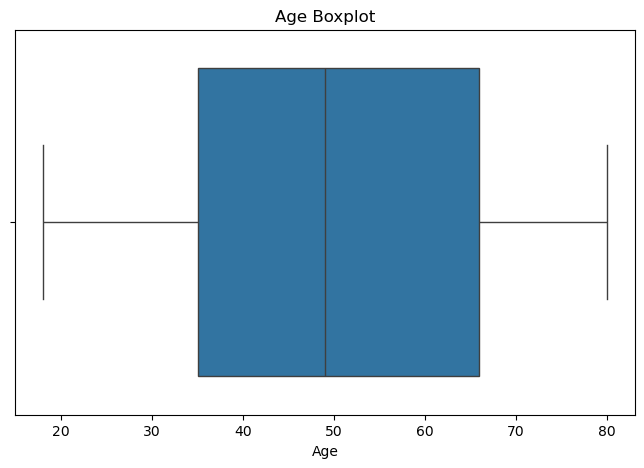

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.show()

In [75]:
# The age distribution does not show significant outliers,
# and values are fairly evenly distributed.

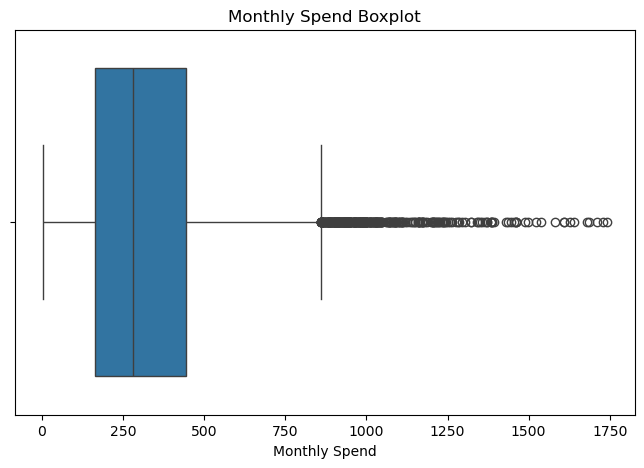

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['MonthlySpend'])
plt.title("Monthly Spend Boxplot")
plt.xlabel("Monthly Spend")
plt.show()

In [77]:
# The distribution of Monthly Spend is right-skewed,
# meaning most customers spend lower amounts while a few customers spend significantly higher.

# Most customers spend between 200 to 500 USD per month,
# while a small number of customers spend up to ~1700 USD, indicating outliers.

# Bar Charts

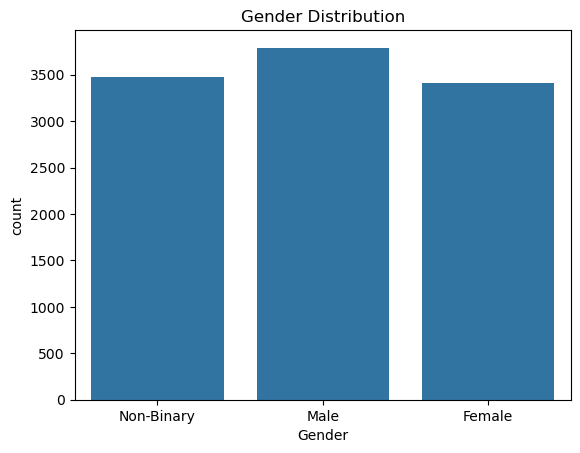

In [83]:
# Gender
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

In [84]:
# Gender distribution is fairly balanced across Male, Female, and Non-Binary categories.

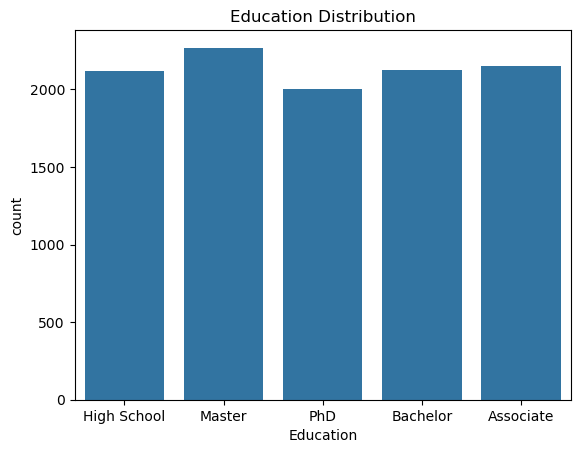

In [85]:
# Education
sns.countplot(x='Education', data=df)
plt.title("Education Distribution")
plt.show()

In [86]:
# Customers are fairly evenly distributed across education levels, with a slight concentration in Master's degree holders.

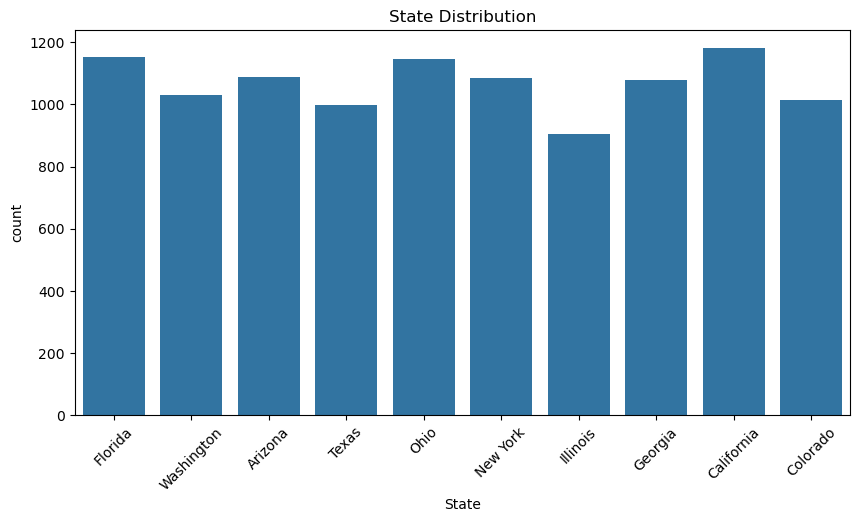

In [87]:
# State
plt.figure(figsize=(10,5))
sns.countplot(x='State', data=df)
plt.title("State Distribution")
plt.xticks(rotation=45)
plt.show()

In [88]:
# Customers are distributed across states with California having slightly higher representation, but overall distribution is fairly balanced.

# Scatter Plot

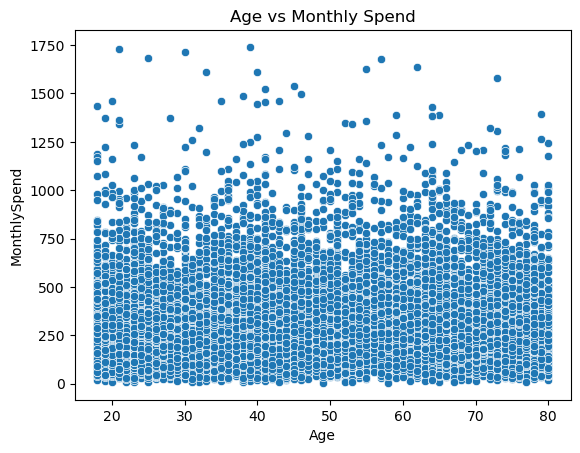

In [89]:
sns.scatterplot(x='Age', y='MonthlySpend', data=df)
plt.title("Age vs Monthly Spend")
plt.show()

In [94]:
# The scatter plot shows that customers across all age groups (18–80)
# exhibit a wide range of spending behavior.

# There is no clear linear relationship between Age and Monthly Spend,
# indicating that spending is not strongly dependent on age.

# A few customers across different age groups show significantly higher spending,
# indicating presence of high-value customers.

# KDE Plot 

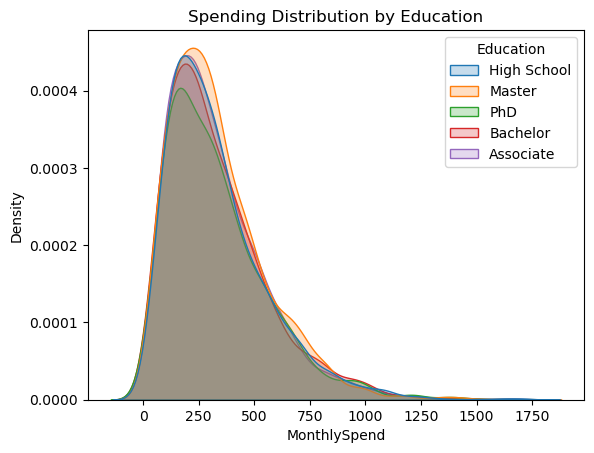

In [90]:
sns.kdeplot(data=df, x='MonthlySpend', hue='Education', fill=True)
plt.title("Spending Distribution by Education")
plt.show()

In [95]:
# The KDE plot shows that spending patterns are similar across different education levels,
# with most customers spending in the lower to mid range.

# However, slight variations suggest that some education groups may have marginally higher spending tendencies.

## Visualization Insights

In [132]:
# Age is fairly evenly distributed across customers, indicating a diverse age group.

# Monthly Spend is right-skewed, showing that most customers spend moderate amounts,
# while a few customers contribute significantly higher spending.

# Boxplot confirms presence of outliers in Monthly Spend, indicating high-value customers.

# Gender, Education, and State distributions are relatively balanced across categories.

# Scatter plot shows no strong linear relationship between Age and Monthly Spend,
# indicating that spending behavior is independent of age.

# KDE plot suggests that spending distributions are similar across education levels,
# with slight variations among groups.

# Bivariate Analysis

## Correlation Matrix

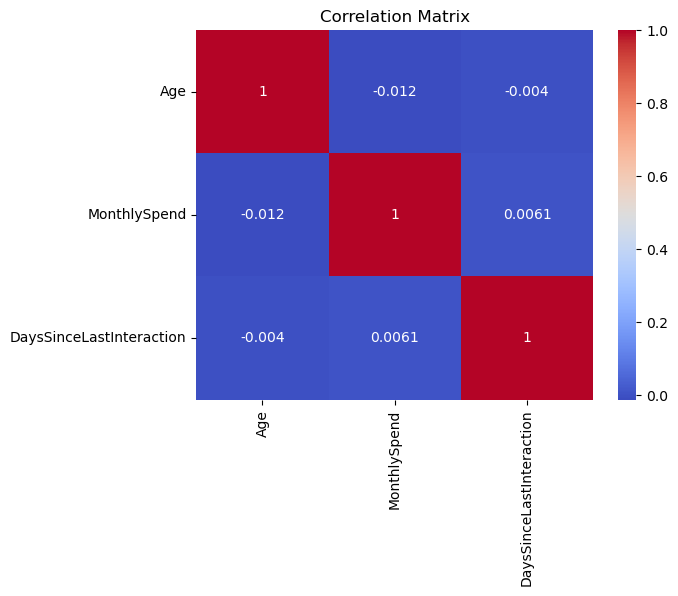

In [97]:
corr = df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [104]:
# Correlation between Age and Monthly Spend is very close to zero,
# indicating no significant relationship between these variables.

# Similarly, DaysSinceLastInteraction also shows no strong correlation
# with other variables.

## Crosstab (Gender vs Married)

In [103]:
pd.crosstab(df['Gender'], df['Married'])

Married,No,Yes
Gender,,
Female,1797,1616
Male,1892,1899
Non-Binary,1894,1577


In [106]:
# The distribution of married and unmarried customers is fairly balanced across all gender categories.
# There is no strong dominance of a particular marital status within any gender group.

# Grouped Analysis

In [99]:
df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False)

State
Arizona       341.489135
Ohio          340.187860
California    339.183492
Illinois      332.589591
New York      332.151244
Washington    329.444078
Georgia       328.354648
Florida       327.696892
Colorado      323.083462
Texas         319.506770
Name: MonthlySpend, dtype: float64

In [105]:
# Customers from Arizona and Ohio show slightly higher average monthly spending,
# while Texas and Colorado have relatively lower spending.

# However, the difference across states is not very large,
# indicating spending behavior is fairly consistent geographically.

In [101]:
df.groupby('Education')['MonthlySpend'].mean().sort_values(ascending=False)

Education
Master         334.252305
High School    332.215712
Bachelor       331.884753
PhD            331.690090
Associate      327.884408
Name: MonthlySpend, dtype: float64

In [107]:
# Customers with a Master’s degree have slightly higher average spending,
# followed closely by other education levels.

# Overall, spending differences across education levels are minimal,
# suggesting education does not strongly influence spending behavior.

In [102]:
df.groupby('Gender')['MonthlySpend'].mean()

Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64

In [108]:
# Average monthly spending is very similar across all gender categories,
# indicating that gender does not significantly impact spending behavior.

## Bivariate Analysis Insights

In [109]:
# Correlation analysis shows no strong relationship between Age, Monthly Spend,
# and Days Since Last Interaction, as correlation values are close to zero.

# Crosstab analysis indicates that marital status distribution is fairly balanced
# across different gender categories.

# State-wise analysis shows slight variation in average spending,
# but overall customer spending is fairly consistent across states.

# Education-wise analysis reveals minimal differences in spending,
# with Master’s degree holders showing slightly higher spending.

# Gender-wise analysis shows that spending behavior is almost identical across all genders,
# indicating no significant impact of gender on spending.

# Hypothesis Testing

## Formulate Hypotheses

### Do males and females spend differently?

#### Define Hypothesis

In [111]:
# H0 (Null Hypothesis): There is NO difference in average MonthlySpend between males and females

# H1 (Alternate Hypothesis): There IS a difference in average MonthlySpend between males and females

In [112]:
from scipy.stats import ttest_ind

male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

t_stat, p_value = ttest_ind(male_spend, female_spend)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.3391730320232445
P-value: 0.7344892727022859


In [117]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [133]:
# The p-value (0.734) is greater than the significance level (0.05),
# so we fail to reject the null hypothesis.

# This indicates that there is no statistically significant difference
# in monthly spending between male and female customers.

# Therefore, gender does not have a significant impact on customer spending behavior.

## TEST 2 (ANOVA)

### Does education level impact monthly spending?|

In [118]:
# H0: There is NO difference in average MonthlySpend across education levels

# H1: There IS a difference in average MonthlySpend across education levels

In [119]:
from scipy.stats import f_oneway

hs = df[df['Education'] == 'High School']['MonthlySpend']
bachelor = df[df['Education'] == 'Bachelor']['MonthlySpend']
master = df[df['Education'] == 'Master']['MonthlySpend']
phd = df[df['Education'] == 'PhD']['MonthlySpend']
associate = df[df['Education'] == 'Associate']['MonthlySpend']

f_stat, p_value = f_oneway(hs, bachelor, master, phd, associate)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.2288066867370917
P-value: 0.922359467759936


In [120]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [121]:
# The p-value (0.922) is significantly greater than the significance level (0.05),
# so we fail to reject the null hypothesis.

# This indicates that there is no statistically significant difference
# in monthly spending across different education levels.

# Therefore, education level does not have a significant impact on customer spending behavior.

# TEST 3 (Chi-Square Test)

## Is marital status related to gender?

In [122]:
# H0: Gender and Marital Status are independent (no relationship)

# H1: Gender and Marital Status are related (dependent)

In [123]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Gender'], df['Married'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 16.01301111700665
P-value: 0.0003332873395557408


In [124]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [125]:
# The p-value (0.00033) is less than the significance level (0.05),
# so we reject the null hypothesis.

# This indicates that there is a statistically significant relationship
# between Gender and Marital Status.

# Therefore, gender and marital status are dependent variables,
# meaning marital status distribution varies across different gender groups.

# TEST 4 (Correlation Hypothesis)

## Are older people less active?

In [126]:
# H0: There is NO correlation between Age and DaysSinceLastInteraction

# H1: There IS a correlation between Age and DaysSinceLastInteraction

In [127]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.003970230104955046
P-value: 0.6816905437300954


In [128]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [129]:
# The correlation value (-0.0039) is very close to zero,
# indicating no linear relationship between Age and DaysSinceLastInteraction.

# The p-value (0.6816) is greater than the significance level (0.05),
# so we fail to reject the null hypothesis.

# This indicates that there is no statistically significant relationship
# between age and customer activity.

# Therefore, older customers are not less active compared to younger customers.

# FINAL BUSINESS INSIGHTS

In [130]:
# Final Business Insights

# 1. Customer spending behavior is not significantly influenced by gender,
# as both male and female customers show similar spending patterns.

# 2. Education level does not have a significant impact on monthly spending,
# indicating that customers across all educational backgrounds spend similarly.

# 3. A statistically significant relationship exists between gender and marital status,
# suggesting that marital patterns vary across different gender groups.

# 4. There is no meaningful relationship between age and customer activity,
# meaning older customers are just as active as younger ones.

# 5. Monthly spending shows high variability with the presence of high-value customers,
# indicating an opportunity for targeted premium marketing strategies.

# 6. Customer distribution across states, education levels, and gender is fairly balanced,
# suggesting a diverse and evenly spread customer base.

# FINAL PROJECT CONCLUSION

In [131]:
# Final Conclusion

# This analysis reveals that customer spending behavior is largely independent of demographic factors
# such as age, gender, and education level.

# However, the presence of high-spending customers highlights opportunities for targeted marketing
# and personalized engagement strategies.

# Additionally, the relationship between gender and marital status suggests potential segmentation
# opportunities for more tailored customer outreach.

# Overall, the business can focus on behavioral patterns rather than demographic assumptions
# to drive data-driven decision making.